## 1. Configuration & Seeding

In [1]:
!pip install -r requirements.txt

  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached matplotlib-3.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (112 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached scipy-1.16.3-cp312-cp312-manylinu

In [14]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import os
import optuna
from optuna.samplers import TPESampler
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [15]:
# Ensure GPU is used if available
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("✅ GPU detected. Using CUDA for training.")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ GPU not detected. Using CPU for training.")

✅ GPU detected. Using CUDA for training.


In [16]:
def seed_everything(seed=42):
    """Set seeds for reproducibility"""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Processing on: {DEVICE}")

# Fixed Settings
BATCH_SIZE = 64
N_TRIALS = 20  # Number of Optuna trials
FINAL_EPOCHS = 50  # Epochs for final training

print(f"Batch Size: {BATCH_SIZE}")
print(f"Optuna Trials: {N_TRIALS}")
print(f"Final Training Epochs: {FINAL_EPOCHS}")

✅ Processing on: cuda
Batch Size: 64
Optuna Trials: 20
Final Training Epochs: 50


## 2. Data Loading & Feature Engineering

In [17]:
def create_advanced_features(df):
    """Create advanced engineered features"""
    df = df.copy()
    
    # Age-related features
    df['age_years_ratio'] = df['founder_age'] / (df['years_with_startup'] + 1)
    
    # Business metrics
    df['annual_revenue_estimate'] = df['monthly_revenue_generated'] * 12
    
    # Experience ratios
    df['tenure_ratio'] = df['years_with_startup'] / (df['founder_age'] + 1)
    
    # Polynomial features for key metrics
    df['revenue_sq'] = df['monthly_revenue_generated'] ** 2
    df['age_sq'] = df['founder_age'] ** 2
    
    return df

print("[1/6] Loading dropped column data...")
try:
    train_df = pd.read_csv('./train_dropped_column.csv')
    test_df = pd.read_csv('./test_dropped_column.csv')
    print(f"✓ Training data loaded: {train_df.shape}")
    print(f"✓ Test data loaded: {test_df.shape}")
except FileNotFoundError:
    print("❌ Error: Dropped column data files not found.")
    raise

# Apply feature engineering
train_df = create_advanced_features(train_df)
test_df = create_advanced_features(test_df)
print("✓ Feature engineering completed")


[1/6] Loading dropped column data...
✓ Training data loaded: (59608, 23)
✓ Test data loaded: (14900, 22)
✓ Feature engineering completed


In [18]:
print("[2/6] Preparing features and target...")

# Separate features and target
X = train_df.drop(['retention_status', 'founder_id'], axis=1)
y = train_df['retention_status']

# Store test IDs
test_ids = test_df['founder_id'].copy()
X_test = test_df.drop(['founder_id'], axis=1)

print(f"✓ Features shape: {X.shape}")
print(f"✓ Test shape: {X_test.shape}")
print(f"✓ Target distribution:\n{y.value_counts()}")

[2/6] Preparing features and target...
✓ Features shape: (59608, 26)
✓ Test shape: (14900, 26)
✓ Target distribution:
retention_status
Stayed    31264
Left      28344
Name: count, dtype: int64


## 3. Preprocessing (Embeddings + Scaling)

In [19]:
print("[3/6] Encoding and scaling features...")

# Identify categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"✓ Categorical columns: {len(cat_cols)}")
print(f"✓ Numerical columns: {len(num_cols)}")
print(f"\nCategorical: {cat_cols}")

# Encode categorical variables and calculate embedding dimensions
cat_dims = []
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    # Combine train and test for consistent encoding
    full_data = pd.concat([X[col], X_test[col]], axis=0).astype(str)
    le.fit(full_data)
    
    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le
    
    num_classes = len(le.classes_)
    emb_dim = min(50, (num_classes + 1) // 2)
    cat_dims.append((num_classes, emb_dim))
    print(f"  {col}: {num_classes} classes -> embedding dim {emb_dim}")

print("\n✓ Categorical encoding completed")

[3/6] Encoding and scaling features...
✓ Categorical columns: 15
✓ Numerical columns: 11

Categorical: ['founder_gender', 'founder_role', 'work_life_balance_rating', 'venture_satisfaction', 'startup_performance_rating', 'working_overtime', 'education_background', 'personal_status', 'startup_stage', 'team_size_category', 'remote_operations', 'leadership_scope', 'innovation_support', 'startup_reputation', 'founder_visibility']
  founder_gender: 2 classes -> embedding dim 1
  founder_role: 5 classes -> embedding dim 3
  work_life_balance_rating: 4 classes -> embedding dim 2
  venture_satisfaction: 4 classes -> embedding dim 2
  startup_performance_rating: 4 classes -> embedding dim 2
  working_overtime: 2 classes -> embedding dim 1
  education_background: 5 classes -> embedding dim 3
  personal_status: 3 classes -> embedding dim 2
  startup_stage: 3 classes -> embedding dim 2
  team_size_category: 3 classes -> embedding dim 2
  remote_operations: 2 classes -> embedding dim 1
  leadership_

In [20]:
# Scale numerical features
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("✓ Numerical scaling completed")

# Prepare arrays for PyTorch
X_cat = X[cat_cols].values.astype(np.int64)
X_num = X[num_cols].values.astype(np.float32)
X_test_cat = X_test[cat_cols].values.astype(np.int64)
X_test_num = X_test[num_cols].values.astype(np.float32)

print(f"\n✓ Categorical features shape: {X_cat.shape}")
print(f"✓ Numerical features shape: {X_num.shape}")

✓ Numerical scaling completed

✓ Categorical features shape: (59608, 15)
✓ Numerical features shape: (59608, 11)


In [21]:
# Encode target variable
target_le = LabelEncoder()
y_encoded = target_le.fit_transform(y)
num_classes_target = len(target_le.classes_)

print(f"✓ Target classes: {target_le.classes_}")
print(f"✓ Number of classes: {num_classes_target}")

# Compute class weights for balanced training
class_weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print(f"✓ Class weights: {class_weights}")

✓ Target classes: ['Left' 'Stayed']
✓ Number of classes: 2
✓ Class weights: [1.05151002 0.95330092]


## 4. Define Model Architecture

In [22]:
class AdvancedTabularDataset(Dataset):
    """Custom Dataset for tabular data with categorical and numerical features"""
    def __init__(self, x_cat, x_num, y=None):
        self.x_cat = torch.tensor(x_cat, dtype=torch.long)
        self.x_num = torch.tensor(x_num, dtype=torch.float)
        self.y = torch.tensor(y, dtype=torch.long) if y is not None else None
    
    def __len__(self):
        return len(self.x_cat)
    
    def __getitem__(self, idx):
        if self.y is not None:
            return self.x_cat[idx], self.x_num[idx], self.y[idx]
        return self.x_cat[idx], self.x_num[idx]

print("✓ Dataset class defined")

✓ Dataset class defined


In [23]:
class DynamicTabularModel(nn.Module):
    """Advanced Neural Network with embeddings for categorical features"""
    def __init__(self, cat_dims, num_dim, output_dim, 
                 l1_size, l2_size, l3_size, 
                 emb_dropout, hidden_dropout):
        super(DynamicTabularModel, self).__init__()
        
        # Embedding layers for categorical features
        self.embeddings = nn.ModuleList([
            nn.Embedding(n, d) for n, d in cat_dims
        ])
        self.emb_dropout = nn.Dropout(emb_dropout)
        total_emb_dim = sum([d for _, d in cat_dims])
        
        # Input batch normalization
        input_dim = total_emb_dim + num_dim
        self.bn0 = nn.BatchNorm1d(num_dim)
        
        # Layer 1
        self.fc1 = nn.Linear(input_dim, l1_size)
        self.bn1 = nn.BatchNorm1d(l1_size)
        self.act1 = nn.GELU()
        self.drop1 = nn.Dropout(hidden_dropout)
        
        # Layer 2
        self.fc2 = nn.Linear(l1_size, l2_size)
        self.bn2 = nn.BatchNorm1d(l2_size)
        self.act2 = nn.GELU()
        self.drop2 = nn.Dropout(hidden_dropout)
        
        # Layer 3
        self.fc3 = nn.Linear(l2_size, l3_size)
        self.bn3 = nn.BatchNorm1d(l3_size)
        self.act3 = nn.GELU()
        self.drop3 = nn.Dropout(hidden_dropout / 2)
        
        # Output layer
        self.output = nn.Linear(l3_size, output_dim)
        
    def forward(self, x_cat, x_num):
        # Process embeddings
        emb_list = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x_emb = self.emb_dropout(torch.cat(emb_list, dim=1))
        
        # Process numerical features
        x_num = self.bn0(x_num)
        
        # Concatenate all features
        x = torch.cat([x_emb, x_num], dim=1)
        
        # Forward through layers
        x = self.drop1(self.act1(self.bn1(self.fc1(x))))
        x = self.drop2(self.act2(self.bn2(self.fc2(x))))
        x = self.drop3(self.act3(self.bn3(self.fc3(x))))
        
        return self.output(x)

print("✓ Model architecture defined")

✓ Model architecture defined


## 5. Optuna Hyperparameter Tuning

In [24]:
print(f"[4/6] Starting Optuna Tuning ({N_TRIALS} Trials)...")
print("-" * 80)

def objective(trial):
    """FAST + PRUNED Optuna objective function"""

    # --- Lightweight search space (MUCH FASTER) ---
    l1_size = trial.suggest_categorical('l1_size', [64, 128, 256])
    l2_size = trial.suggest_categorical('l2_size', [32, 64, 128])
    l3_size = trial.suggest_categorical('l3_size', [16, 32, 64])

    emb_dropout = trial.suggest_float('emb_dropout', 0.1, 0.4)
    hidden_dropout = trial.suggest_float('hidden_dropout', 0.1, 0.4)

    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    # 2-fold CV (much faster, still reliable)
    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED)
    scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_num, y_encoded)):

        # Dataset & loaders
        train_ds = AdvancedTabularDataset(X_cat[train_idx], X_num[train_idx], y_encoded[train_idx])
        val_ds = AdvancedTabularDataset(X_cat[val_idx], X_num[val_idx], y_encoded[val_idx])

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)

        # Model
        model = DynamicTabularModel(
            cat_dims, X_num.shape[1], num_classes_target,
            l1_size, l2_size, l3_size, emb_dropout, hidden_dropout
        ).to(DEVICE)

        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

        # --- FAST training: only 8 epochs ---
        for epoch in range(8):
            model.train()
            for c, n, y_batch in train_loader:
                c, n, y_batch = c.to(DEVICE), n.to(DEVICE), y_batch.to(DEVICE)

                optimizer.zero_grad()
                loss = criterion(model(c, n), y_batch)
                loss.backward()
                optimizer.step()

            # Validate each epoch (for pruning)
            model.eval()
            preds, labels = [], []
            with torch.no_grad():
                for c, n, y_batch in val_loader:
                    c, n = c.to(DEVICE), n.to(DEVICE)
                    p = torch.argmax(model(c, n), dim=1)
                    preds.extend(p.cpu().numpy())
                    labels.extend(y_batch.numpy())

            val_acc = accuracy_score(labels, preds)

            # Report accuracy per epoch for early pruning
            trial.report(val_acc, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        scores.append(val_acc)

    # Return mean accuracy across folds
    return np.mean(scores)

print("✓ Optimized objective function ready")


[4/6] Starting Optuna Tuning (20 Trials)...
--------------------------------------------------------------------------------
✓ Optimized objective function ready


In [27]:
 # ---- RUN OPTUNA STUDY ----
sampler = TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)

print("\n🚀 Running Optuna study...\n")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

# ---- PRINT BEST PARAMETERS ----
print("\n" + "="*80)
print("🎉 BEST HYPERPARAMETERS FOUND")
print("="*80)

best_p = study.best_params
for k, v in best_p.items():
    print(f"{k}: {v}")

print("="*80)

[I 2025-11-27 13:11:01,716] A new study created in memory with name: no-name-4b8094b0-0336-4e13-91e3-8d46681c0381



🚀 Running Optuna study...



  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-27 13:11:46,947] Trial 0 finished with value: 0.7441618574687962 and parameters: {'l1_size': 128, 'l2_size': 32, 'l3_size': 32, 'emb_dropout': 0.3124217733388137, 'hidden_dropout': 0.10617534828874074, 'lr': 0.0044447541666908135, 'weight_decay': 0.0003142880890840109}. Best is trial 0 with value: 0.7441618574687962.
[I 2025-11-27 13:12:32,278] Trial 1 finished with value: 0.7401019997315796 and parameters: {'l1_size': 64, 'l2_size': 64, 'l3_size': 32, 'emb_dropout': 0.18764339456056545, 'hidden_dropout': 0.20990855298810754, 'lr': 0.0005954553793888993, 'weight_decay': 0.0002267398652378039}. Best is trial 0 with value: 0.7441618574687962.
[I 2025-11-27 13:13:17,193] Trial 2 finished with value: 0.7079586632666757 and parameters: {'l1_size': 256, 'l2_size': 64, 'l3_size': 64, 'emb_dropout': 0.3425192044349384, 'hidden_dropout': 0.19138413075201122, 'lr': 0.00014653521030672147, 'weight_decay': 0.00011290133559092664}. Best is trial 0 with value: 0.7441618574687962.
[I 2025-

## 6. Final Training with Best Parameters

In [28]:
print("\n" + "=" * 80)
print("[5/6] Retraining Final Model with Best Params (5 Folds)")
print("=" * 80)

skf_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
test_probs_sum = np.zeros((len(X_test), num_classes_target))
final_scores = []
fold_models = []

for fold, (train_idx, val_idx) in enumerate(skf_final.split(X_num, y_encoded)):
    print(f"\n--- Fold {fold+1}/5 ---")
    
    # Create datasets
    train_ds = AdvancedTabularDataset(X_cat[train_idx], X_num[train_idx], y_encoded[train_idx])
    val_ds = AdvancedTabularDataset(X_cat[val_idx], X_num[val_idx], y_encoded[val_idx])
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)
    
    # Create model with best parameters
    model = DynamicTabularModel(
        cat_dims, X_num.shape[1], num_classes_target,
        best_p['l1_size'], best_p['l2_size'], best_p['l3_size'],
        best_p['emb_dropout'], best_p['hidden_dropout']
    ).to(DEVICE)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=best_p['lr'], weight_decay=best_p['weight_decay'])
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=best_p['lr']*10, 
        steps_per_epoch=len(train_loader), 
        epochs=FINAL_EPOCHS
    )
    
    best_val_acc = 0
    best_state = None
    patience_counter = 0
    
    # Training loop
    for epoch in range(FINAL_EPOCHS):
        model.train()
        train_loss = 0
        for c, n, y_batch in train_loader:
            c, n, y_batch = c.to(DEVICE), n.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(c, n), y_batch)
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for c, n, y_batch in val_loader:
                c, n = c.to(DEVICE), n.to(DEVICE)
                p = torch.argmax(model(c, n), dim=1)
                preds.extend(p.cpu().numpy())
                labels.extend(y_batch.numpy())
        
        val_acc = accuracy_score(labels, preds)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{FINAL_EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f} | Best: {best_val_acc:.4f}")
    
    print(f"✓ Fold {fold+1} Best Accuracy: {best_val_acc:.4f}")
    final_scores.append(best_val_acc)
    
    # Load best model and predict on test
    model.load_state_dict(best_state)
    model.eval()
    
    test_ds = AdvancedTabularDataset(X_test_cat, X_test_num)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)
    
    fold_probs = []
    with torch.no_grad():
        for c, n in test_loader:
            c, n = c.to(DEVICE), n.to(DEVICE)
            probs = torch.softmax(model(c, n), dim=1)
            fold_probs.append(probs.cpu().numpy())
    
    test_probs_sum += np.concatenate(fold_probs)
    fold_models.append(model.state_dict())

print("\n" + "=" * 80)
print(f"🏆 Final Average Accuracy: {np.mean(final_scores):.4f} (+/- {np.std(final_scores):.4f})")
print(f"   Fold Scores: {[f'{s:.4f}' for s in final_scores]}")
print("=" * 80)


[5/6] Retraining Final Model with Best Params (5 Folds)

--- Fold 1/5 ---
Epoch 10/50 | Train Loss: 0.5618 | Val Acc: 0.7429 | Best: 0.7566
Epoch 20/50 | Train Loss: 0.5587 | Val Acc: 0.7403 | Best: 0.7573
Epoch 30/50 | Train Loss: 0.5542 | Val Acc: 0.7587 | Best: 0.7587
Epoch 40/50 | Train Loss: 0.5488 | Val Acc: 0.7555 | Best: 0.7587
Epoch 50/50 | Train Loss: 0.5466 | Val Acc: 0.7513 | Best: 0.7587
✓ Fold 1 Best Accuracy: 0.7587

--- Fold 2/5 ---
Epoch 10/50 | Train Loss: 0.5646 | Val Acc: 0.7479 | Best: 0.7480
Epoch 20/50 | Train Loss: 0.5582 | Val Acc: 0.7495 | Best: 0.7510
Epoch 30/50 | Train Loss: 0.5532 | Val Acc: 0.7504 | Best: 0.7542
Epoch 40/50 | Train Loss: 0.5467 | Val Acc: 0.7501 | Best: 0.7542
Epoch 50/50 | Train Loss: 0.5447 | Val Acc: 0.7510 | Best: 0.7542
✓ Fold 2 Best Accuracy: 0.7542

--- Fold 3/5 ---
Epoch 10/50 | Train Loss: 0.5620 | Val Acc: 0.7462 | Best: 0.7483
Epoch 20/50 | Train Loss: 0.5579 | Val Acc: 0.7480 | Best: 0.7516
Epoch 30/50 | Train Loss: 0.5527 | 

## 7. Save Results

In [29]:
print("\n[6/6] Generating predictions and saving results...")

# Average predictions across folds
avg_test_probs = test_probs_sum / 5

# Save probability predictions
prob_df = pd.DataFrame(avg_test_probs, columns=[f'prob_{cls}' for cls in target_le.classes_])
prob_df['founder_id'] = test_ids.values
prob_df.to_csv('nn_optuna_probs.csv', index=False)
print("✅ Saved 'nn_optuna_probs.csv'")

# Create submission file
final_indices = np.argmax(avg_test_probs, axis=1)
final_labels = target_le.inverse_transform(final_indices)

submission_df = pd.DataFrame({
    'founder_id': test_ids,
    'retention_status': final_labels
})
submission_df.to_csv('submission_nn_optuna.csv', index=False)
print("✅ Saved 'submission_nn_optuna.csv'")

# Display prediction distribution
print("\nPrediction distribution:")
print(submission_df['retention_status'].value_counts())


[6/6] Generating predictions and saving results...
✅ Saved 'nn_optuna_probs.csv'
✅ Saved 'submission_nn_optuna.csv'

Prediction distribution:
retention_status
Left      7684
Stayed    7216
Name: count, dtype: int64


## 8. Visualize Results

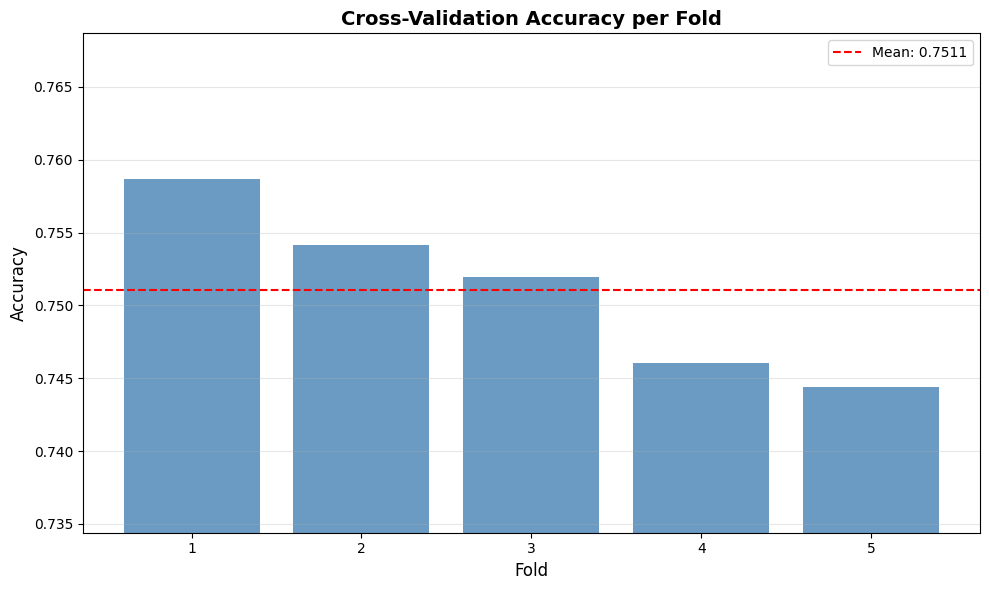

In [30]:
# Plot fold scores
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), final_scores, color='steelblue', alpha=0.8)
plt.axhline(y=np.mean(final_scores), color='red', linestyle='--', label=f'Mean: {np.mean(final_scores):.4f}')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Cross-Validation Accuracy per Fold', fontsize=14, fontweight='bold')
plt.ylim([min(final_scores) - 0.01, max(final_scores) + 0.01])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

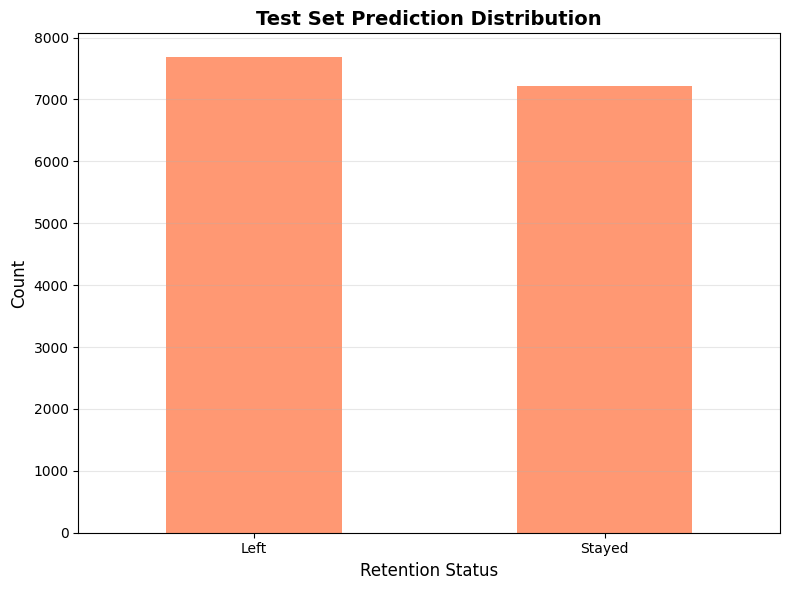

In [31]:
# Plot prediction distribution
plt.figure(figsize=(8, 6))
submission_df['retention_status'].value_counts().plot(kind='bar', color='coral', alpha=0.8)
plt.xlabel('Retention Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Test Set Prediction Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

### Model Configuration:
- **Architecture**: 3-layer neural network with embeddings
- **Optimization**: Optuna with TPE sampler
- **Cross-Validation**: 5-fold stratified
- **Device**: GPU if available, otherwise CPU

### Best Hyperparameters:
See output from Optuna tuning above.

### Final Performance:
Average accuracy across 5 folds displayed above.

### Output Files:
1. `submission_nn_optuna.csv` - Final predictions for submission
2. `nn_optuna_probs.csv` - Class probabilities for each test sample

In [ ]:
print("\n" + "=" * 80)
print("✅ TRAINING COMPLETE!")
print("=" * 80)
print(f"\nFinal Average Accuracy: {np.mean(final_scores):.4f}")
print(f"Standard Deviation: {np.std(final_scores):.4f}")
print("\nOutput files:")
print("  1. submission_nn_optuna.csv - Test predictions")
print("  2. nn_optuna_probs.csv - Prediction probabilities")